# Smart RFP / Compliance Review Agent — LangGraph Assignment

A multi-node **LangGraph** workflow that reviews contract/RFP clauses for compliance risk,
using a shared typed state, conditional routing, Retrieval-Augmented Generation (RAG),
and a **human-in-the-loop** interrupt for high-risk clauses.

**Graph flow:**

```
intake → classify_clauses → retrieve_context → assess_risk
                                                   │
                                    (conditional edge on risk level)
                                                   │
                              ┌────────────────────┴────────────────────┐
                              ▼                                         ▼
                       human_review (interrupt)                   summarize
                              │                                         ▲
                              └─────────────────────────────────────────┘
```

Built with **LangChain v1** patterns (`create_agent`-era APIs, `InMemorySaver` checkpointer)
and **Google Gemini** for LLM + embeddings.


## 1. Install dependencies

In [ ]:
%pip install -q langgraph langchain langchain-google-genai langchain-chroma chromadb pydantic


## 2. API key setup

Uses Google Gemini. Get a free key at https://aistudio.google.com/apikey and paste it when prompted
(or set the `GOOGLE_API_KEY` environment variable beforehand to skip the prompt).


In [2]:
import os
from getpass import getpass

if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass("Enter your GOOGLE_API_KEY: ")

GOOGLE_API_KEY = os.environ["GOOGLE_API_KEY"]
LLM_MODEL = "gemini-3.5-flash"
EMBEDDING_MODEL = "gemini-embedding-001"


## 3. Define the shared graph state

LangGraph passes a single typed state object between every node. Each node reads
what it needs and returns a partial update that gets merged in.


In [3]:
from typing import TypedDict, List, Optional, Literal
from pydantic import BaseModel, Field


class Clause(TypedDict):
    id: int
    text: str
    category: Optional[str]          # legal / technical / financial
    context: Optional[str]           # retrieved compliance reference
    risk_level: Optional[str]        # low / medium / high
    risk_reason: Optional[str]
    human_decision: Optional[str]    # approved / rejected / not_needed


class ReviewState(TypedDict):
    document_text: str
    clauses: List[Clause]
    needs_human_review: bool
    final_report: Optional[str]


## 4. Sample document

A synthetic RFP/contract excerpt so the notebook runs end-to-end without needing an
uploaded file. Swap this out for real PDF/docx text (e.g. via a `pypdf` loader) in production.


In [4]:
SAMPLE_DOCUMENT = """
1. The contractor shall complete all civil works within 180 days of site handover.
2. Payment terms: 30% advance, 40% on milestone completion, 30% on final acceptance,
   with no penalty clause for delayed government approvals.
3. All structural steel must conform to IS 800:2007 and be certified by a
   third-party inspection agency prior to installation.
4. The contractor may subcontract up to 100% of the work without prior written
   consent from the client.
5. Any disputes shall be resolved through arbitration in a jurisdiction to be
   decided solely by the contractor.
6. Safety equipment and PPE for all site workers must comply with OSHA/BOCW Act
   standards at all times.
"""

## 5. `intake` node — split the document into clauses

The first node in the graph. Pure parsing, no LLM call needed.


In [5]:
import re

def intake_node(state: ReviewState) -> dict:
    raw_lines = [l.strip() for l in state["document_text"].strip().split("\n") if l.strip()]
    clauses: List[Clause] = []
    buf = ""
    idx = 0
    for line in raw_lines:
        if re.match(r"^\d+\.", line):
            if buf:
                clauses.append({"id": idx, "text": buf.strip(), "category": None,
                                 "context": None, "risk_level": None,
                                 "risk_reason": None, "human_decision": None})
                idx += 1
            buf = line
        else:
            buf += " " + line
    if buf:
        clauses.append({"id": idx, "text": buf.strip(), "category": None,
                         "context": None, "risk_level": None,
                         "risk_reason": None, "human_decision": None})
    print(f"[intake] parsed {len(clauses)} clauses")
    return {"clauses": clauses}


## 6. Build the compliance knowledge base (RAG)

A tiny Chroma vector store of compliance/standards reference text, embedded with
Gemini embeddings. `retrieve_context` will query this per clause.


In [6]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_chroma import Chroma
from langchain_core.documents import Document

COMPLIANCE_REFERENCES = [
    "Standard construction contracts should include a penalty/liquidated-damages "
    "clause for delays, including delays attributable to government approvals, "
    "to protect the client's schedule risk.",
    "Structural steel and materials must be certified against IS 800:2007 or "
    "equivalent international standards, with third-party inspection before use.",
    "Subcontracting should be capped (commonly 25-40% of contract value) and "
    "always require prior written client consent to preserve accountability.",
    "Dispute resolution clauses should specify a neutral, mutually agreed "
    "arbitration seat and governing law, not one chosen unilaterally by either party.",
    "All site personnel must be provided PPE and safety training compliant with "
    "the Building and Other Construction Workers (BOCW) Act and OSHA-equivalent norms.",
]

embeddings = GoogleGenerativeAIEmbeddings(model=f"models/{EMBEDDING_MODEL}",
                                           google_api_key=GOOGLE_API_KEY)

vectorstore = Chroma.from_documents(
    documents=[Document(page_content=t) for t in COMPLIANCE_REFERENCES],
    embedding=embeddings,
    collection_name="compliance_kb",
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 1})

llm = ChatGoogleGenerativeAI(model=LLM_MODEL, google_api_key=GOOGLE_API_KEY, temperature=0)
print("Vector store ready with", len(COMPLIANCE_REFERENCES), "reference docs")


Vector store ready with 5 reference docs


## 7. `classify_clauses` node — LLM structured output

Uses `.with_structured_output(...)` (LangChain v1 style) instead of manual JSON parsing.


In [7]:
class ClauseLabel(BaseModel):
    id: int
    category: Literal["legal", "technical", "financial"]

class ClassificationBatch(BaseModel):
    labels: List[ClauseLabel] = Field(description="One label per input clause, matched by id")

classifier_llm = llm.with_structured_output(ClassificationBatch)

def classify_clauses_node(state: ReviewState) -> dict:
    # Batch ALL clauses into ONE call instead of one call per clause
    # (keeps this well under the free-tier daily request quota)
    numbered = "\n".join(f"id={c['id']}: {c['text']}" for c in state["clauses"])
    result = classifier_llm.invoke(
        "Classify each of the following contract clauses into legal, technical, "
        f"or financial. Return one label per id.\n\n{numbered}"
    )
    by_id = {label.id: label.category for label in result.labels}
    updated = [{**c, "category": by_id.get(c["id"], "legal")} for c in state["clauses"]]
    print("[classify] categories:", [(c["id"], c["category"]) for c in updated])
    return {"clauses": updated}


## 8. `retrieve_context` node — RAG lookup per clause

For each clause, pull the most relevant compliance reference to ground the risk assessment.


In [8]:
def retrieve_context_node(state: ReviewState) -> dict:
    updated = []
    for clause in state["clauses"]:
        docs = retriever.invoke(clause["text"])
        context = docs[0].page_content if docs else "No reference found."
        updated.append({**clause, "context": context})
    print("[retrieve] context attached to", len(updated), "clauses")
    return {"clauses": updated}


## 9. `assess_risk` node — score each clause

Compares the clause against the retrieved compliance reference and assigns a risk level.


In [9]:
class ClauseRisk(BaseModel):
    id: int
    risk_level: Literal["low", "medium", "high"]
    reason: str = Field(description="One-sentence justification")

class RiskBatch(BaseModel):
    assessments: List[ClauseRisk] = Field(description="One assessment per input clause, matched by id")

risk_llm = llm.with_structured_output(RiskBatch)

def assess_risk_node(state: ReviewState) -> dict:
    # Batch ALL clauses into ONE call instead of one call per clause
    numbered = "\n\n".join(
        f"id={c['id']}\nCLAUSE: {c['text']}\nREFERENCE: {c['context']}"
        for c in state["clauses"]
    )
    result = risk_llm.invoke(
        "For EACH clause below, compare it against its REFERENCE standard and "
        f"assess compliance risk. Return one assessment per id.\n\n{numbered}"
    )
    by_id = {a.id: a for a in result.assessments}
    updated = []
    any_high = False
    for c in state["clauses"]:
        a = by_id.get(c["id"])
        risk_level = a.risk_level if a else "medium"
        reason = a.reason if a else "No assessment returned."
        if risk_level == "high":
            any_high = True
        updated.append({**c, "risk_level": risk_level, "risk_reason": reason})
    print("[assess_risk] levels:", [(c["id"], c["risk_level"]) for c in updated])
    return {"clauses": updated, "needs_human_review": any_high}


## 10. Conditional edge — route based on risk

This is the core LangGraph concept: the graph branches at runtime based on the state,
instead of following one fixed path.


In [10]:
def route_after_risk(state: ReviewState) -> str:
    return "human_review" if state["needs_human_review"] else "summarize"


## 11. `human_review` node — human-in-the-loop via `interrupt()`

`interrupt()` pauses graph execution and hands control back to the caller. The caller
inspects the payload, then resumes the graph with `Command(resume=...)`. This is the
piece that distinguishes LangGraph from a plain LangChain chain.


In [11]:
from langgraph.types import interrupt

def human_review_node(state: ReviewState) -> dict:
    high_risk = [c for c in state["clauses"] if c["risk_level"] == "high"]

    decisions = interrupt({
        "message": "High-risk clauses need human approval before the report is finalized.",
        "clauses": [{"id": c["id"], "text": c["text"], "reason": c["risk_reason"]} for c in high_risk],
    })
    # `decisions` is whatever value is passed back via Command(resume=decisions).
    # Keys are strings (see note in the invoke cell below) so LangGraph's internal
    # "is this a multi-interrupt resume map?" check doesn't choke on int keys.
    updated = []
    for c in state["clauses"]:
        if c["risk_level"] == "high":
            c = {**c, "human_decision": decisions.get(str(c["id"]), "pending")}
        else:
            c = {**c, "human_decision": "not_needed"}
        updated.append(c)
    return {"clauses": updated}


## 12. `summarize` node — final compliance report

In [12]:
def summarize_node(state: ReviewState) -> dict:
    lines = ["# Compliance Review Report", ""]
    for c in state["clauses"]:
        lines.append(f"### Clause {c['id']} ({c['category']})")
        lines.append(f"> {c['text']}")
        lines.append(f"- Risk: **{c['risk_level']}** — {c['risk_reason']}")
        if c.get("human_decision") and c["human_decision"] != "not_needed":
            lines.append(f"- Human decision: **{c['human_decision']}**")
        lines.append("")
    report = "\n".join(lines)
    print("[summarize] report generated")
    return {"final_report": report}


## 13. Build and compile the graph

Wires all nodes together with `StateGraph`, adds the conditional edge, and compiles
with an `InMemorySaver` checkpointer (required for `interrupt`/resume to work).


In [13]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

builder = StateGraph(ReviewState)

builder.add_node("intake", intake_node)
builder.add_node("classify_clauses", classify_clauses_node)
builder.add_node("retrieve_context", retrieve_context_node)
builder.add_node("assess_risk", assess_risk_node)
builder.add_node("human_review", human_review_node)
builder.add_node("summarize", summarize_node)

builder.add_edge(START, "intake")
builder.add_edge("intake", "classify_clauses")
builder.add_edge("classify_clauses", "retrieve_context")
builder.add_edge("retrieve_context", "assess_risk")
builder.add_conditional_edges("assess_risk", route_after_risk, {
    "human_review": "human_review",
    "summarize": "summarize",
})
builder.add_edge("human_review", "summarize")
builder.add_edge("summarize", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
print("Graph compiled.")


Graph compiled.


## 14. Visualize the graph

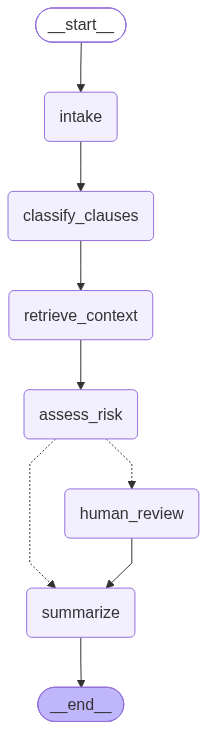

In [14]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Mermaid rendering needs internet access; falling back to ASCII view.")
    print(graph.get_graph().draw_ascii())


## 15. Run the workflow end-to-end

Runs the graph. If it pauses on `human_review`, we inspect the interrupt payload,
make a decision for each flagged clause, and resume with `Command(resume=...)`.


In [15]:
from langgraph.types import Command
import uuid

# Fresh thread_id on every run so re-running this cell never replays a stale checkpoint
config = {"configurable": {"thread_id": f"rfp-review-{uuid.uuid4().hex[:8]}"}}
print("Using thread_id:", config["configurable"]["thread_id"])

result = graph.invoke({"document_text": SAMPLE_DOCUMENT, "clauses": [],
                        "needs_human_review": False, "final_report": None}, config=config)

if "__interrupt__" in result:
    payload = result["__interrupt__"][0].value
    print(payload["message"])
    for c in payload["clauses"]:
        print(f"  Clause {c['id']}: {c['text']}")
        print(f"    reason: {c['reason']}")

    # --- Simulated human decisions (in a real app, capture these from a UI) ---
    # NOTE: keys must be strings, not ints -- LangGraph inspects dict keys of a
    # Command(resume=...) payload to see if they look like interrupt-id hashes,
    # and that check errors out on non-string keys.
    decisions = {str(c["id"]): "approved" for c in payload["clauses"]}
    print("\nSimulated human decisions:", decisions)

    result = graph.invoke(Command(resume=decisions), config=config)
else:
    print("No high-risk clauses — no human review needed.")


Using thread_id: rfp-review-681a3893
[intake] parsed 6 clauses
[classify] categories: [(0, 'technical'), (1, 'financial'), (2, 'technical'), (3, 'legal'), (4, 'legal'), (5, 'technical')]
[retrieve] context attached to 6 clauses
[assess_risk] levels: [(0, 'high'), (1, 'high'), (2, 'low'), (3, 'high'), (4, 'high'), (5, 'medium')]
High-risk clauses need human approval before the report is finalized.
  Clause 0: 1. The contractor shall complete all civil works within 180 days of site handover.
    reason: The clause completely fails to address the required safety training and PPE compliance standards specified in the reference.
  Clause 1: 2. Payment terms: 30% advance, 40% on milestone completion, 30% on final acceptance, with no penalty clause for delayed government approvals.
    reason: The clause explicitly excludes penalties for delayed government approvals, directly contradicting the reference standard's requirement to protect schedule risk.
  Clause 3: 4. The contractor may subcont

## 16. Final report

In [16]:
from IPython.display import Markdown, display

display(Markdown(result["final_report"]))


# Compliance Review Report

### Clause 0 (technical)
> 1. The contractor shall complete all civil works within 180 days of site handover.
- Risk: **high** — The clause completely fails to address the required safety training and PPE compliance standards specified in the reference.
- Human decision: **approved**

### Clause 1 (financial)
> 2. Payment terms: 30% advance, 40% on milestone completion, 30% on final acceptance, with no penalty clause for delayed government approvals.
- Risk: **high** — The clause explicitly excludes penalties for delayed government approvals, directly contradicting the reference standard's requirement to protect schedule risk.
- Human decision: **approved**

### Clause 2 (technical)
> 3. All structural steel must conform to IS 800:2007 and be certified by a third-party inspection agency prior to installation.
- Risk: **low** — The clause fully complies with the reference standard by requiring IS 800:2007 conformity and third-party certification prior to installation.

### Clause 3 (legal)
> 4. The contractor may subcontract up to 100% of the work without prior written consent from the client.
- Risk: **high** — The clause allows 100% subcontracting without consent, violating the reference standard which requires capped subcontracting and prior written client approval.
- Human decision: **approved**

### Clause 4 (legal)
> 5. Any disputes shall be resolved through arbitration in a jurisdiction to be decided solely by the contractor.
- Risk: **high** — The clause permits unilateral jurisdiction selection by the contractor, violating the reference standard's requirement for a neutral, mutually agreed arbitration seat.
- Human decision: **approved**

### Clause 5 (technical)
> 6. Safety equipment and PPE for all site workers must comply with OSHA/BOCW Act standards at all times.
- Risk: **medium** — The clause covers PPE compliance with OSHA and BOCW standards but fails to explicitly mandate the safety training required by the reference standard.


---

### Ideas for extending this for extra credit

- Swap `SAMPLE_DOCUMENT` for a real uploaded PDF using a `pypdf`/`langchain` document loader.
- Use `Send()` to fan the `assess_risk` step out across clauses in parallel (map-reduce pattern).
- Persist `checkpointer` to SQLite (`langgraph.checkpoint.sqlite.SqliteSaver`) so review sessions survive a restart.
- Add a second conditional edge that loops a rejected clause back to `assess_risk` for renegotiation.
